## 3. Module 2 — Graph-Based Analysis
**Initial task description (Module 2 perspective):**
Building upon our structural discoveries from Module 1, our second analysis phase shifts the focus from global geometric alignment to local topological structures. Evidence suggests that calculating classical distances across a sparse, high dimensional text space is inherently noisy, which is not ideal to capture the nuanced semantic boundaries. To address this limitation, we model the data as a graph, transforming textual similarities into a network topology.

We implemented two graph mining algorithms to identify these contextual boundaries. We selected Spectral Clustering and the Louvain method because they represent two fundamentally opposing topological paradigms: top-down global partitioning and bottom-up local agglomeration. While our overarching shift to a graph-based approach aims to structurally mitigate the spatial "gravity well" effect, the juxtaposition of these specific algorithms provides deeper behavioral insight. Specifically, it evaluates whether the human musical curation landscape is more accurately modeled as a globally partitioned space defined by distinct boundaries, or as a locally agglomerated space driven by internal cohesion.

### Reproducibility and setup

In [9]:
# Imports
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import networkx as nx

In [10]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [11]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


### Preprocessing
The primary preprocessing step in this phase involves converting our global TF-IDF matrix into a local k-NN similarity graph. We chose this text-based graph conversion method over a behavior-based (such as a shared-track bipartite graph) for three methodological reasons: it preserves our core research question regarding the semantic value of playlist names, it ensures a controlled comparison against our baseline by keeping the input features constant, and it acts as a structural remedy to the "gravity well" effect observed part 1 by mathematically severing generic ties and isolating relevant local neighborhoods.

To do this, we calculate the Cosine Similarity using the values of the TF-IDF between each playlist. Thereafter we sparsify the values, converting all but the top 10 highest numbers for each row to 0. The result is a weighted adjacency matrix where each playlist is a node, and every non-zero number becomes an edge. We choose k to be 10 to ensure inclusivity while preventing massive node hubs, and we define a minimum threshold of 0.15 to ensure we don't force connections of low quality.

Crucially, this process provides new opportunities for structural analysis that traditional geometric clustering cannot offer. The new network representation allows us to model musical curation as interconnected communities, which establishes the ideal foundational topology for our graph mining methodologies, which identify natural boundaries based on network density rather than global spatial distance.

In [12]:
from graph.knn.knn_graph import KNNGraph
from notebook_helper import build_graph, build_digraph

In [13]:
graph_builder = KNNGraph(k_neighbors=10, sim_threshold=0.15)
graph_config_name = build_graph(graph_builder, unique_texts, tfidf_matrix)
digraph_config_name = build_digraph(graph_builder, unique_texts, tfidf_matrix)


[INFO] Loading previously built k-NN graph from graph/knn/saved_graphs/knn_k10_sim0.15_N84696.pkl...

[INFO] Loading previously built directed k-NN graph from graph/knn/saved_graphs/digraph_k10_sim0.15_N84696_mknn.pkl...


### Louvain Community Detection
The Louvain method is a heuristic bottom up approach designed to discover communities by Maximizing Modularity.
Modularity is a scalar value that quantifies the density of a random graph. The algorithm operates in a continuous 2
phase loop, phase 1 allowing nodes to iteratively jump to neighboring communities that yield the highest increase in
modularity, and phase 2 aggregating the communities into "super nodes". This continues until the global modularity can
no longer be improved. This allows the method to discover the optimal communities.
We specifically chose the Louvain method over Ravasz and link clustering as both run O($n^2$) complexity, as
opposed to Louvain’s O($m$).

#### Executing Louvain Community Detection - $k = 322$
We execute the Louvain algorithm using the python-louvain library, specifically invoking the best_partition() function on our interconnected network of playlists.

When invoking the algorithm, we pass our k-NN graph directly into the function without explicitly overriding the default hyperparameters. We designed our execution strategy around two default parameters:

- **weight='weight'**: Modularity works by evaluating edge densities. We explicitly stored our TF-IDF cosine similarities under the "weight" edge attribute during the k-NN graph construction and hence Louvain automatically detects and leverages this data. This  upgrades the algorithm from evaluating basic, binary network connections to evaluating the contextual equivalence between playlists.
- **resolution=1.0**: As we are basing our project on structure discovery, we define the default resolution, as this is where the modularity equation is balanced and where clusters are defined naturally based on density.

In [14]:
# Initialize Louvain Clustering instance, and load the graph from the shared builder
from graph.knn.louvain_clustering import LouvainClustering
Louvain = LouvainClustering(graph=graph_builder.G, graph_config_name=graph_config_name, random_state=RANDOM_SEED)

In [15]:
# importing the execution pipeline helper function
from notebook_helper import execution_pipeline
execution_pipeline(Louvain, df, unique_texts, tfidf_matrix)

Checking for: 'louvain_community_labels_42' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Louvain already exists in column 'louvain_community_labels_42'.


### Spectral Clustering
Spectral Clustering is a deterministic partitioning technique rooted in linear algebra that identifies optimal global cuts.
It uses the Laplacian matrix to find eigenvectors/eigenvalues and uses them to project the complex topology into a
lower dimensional spectral space. Dense communities mathematically pull apart, and K-means can be applied to find k
distinct partitions.
We specifically chose Spectral Clustering as opposed to similar alternatives due to its performance on sparse
k-NN graphs, in which libraries like scikit-learn allows complexity of $O(km)$ (where $m$ is the number of edges.)

#### Executing Spectral Clustering - $k = 322$
To execute the algorithm, we utilize the SpectralClustering implementation from the scikit-learn library. Spectral Clustering requires a mathematical representation of our interconnected network. We translate our networkx k-NN graph into a SciPy sparse adjacency matrix, explicitly ensuring that the algorithm inherits our TF-IDF cosine similarities by preserving the edge weight attributes.

We instantiate the model with the following hyperparameters:
- **n_clusters=???**: We match it with the final cluster value from Louvain, for a fair comparison.
- **affinity="precomputed"**: This parameter instructs the algorithm to bypass its internal similarity calculations and instead accept our spatial matrix. We chose this to ensure the model evaluates the network based on the TF-IDF cosine similarities we established during the k-NN graph construction.
- **eigen_solver="arpack"**: The ARPACK solver was explicitly chosen over standard solvers because it is mathematically much more stable when handling disjointed network topologies such as ours.
- **assign_labels="cluster_qr"**: We use QR decomposition for the final labeling step rather than the default k-means approach, as it provides a significantly faster and strictly deterministic result.

In [16]:
# Initialize Spectral Clustering instance, and load the graph from the shared builder
from graph.knn.spectral_clustering import SpectralGraphClustering
Spectral_322 = SpectralGraphClustering(graph=graph_builder.G, n_clusters=322, graph_config_name=graph_config_name)

In [17]:
# importing the execution pipeline helper function
from notebook_helper import execution_pipeline
execution_pipeline(Spectral_322, df, unique_texts, tfidf_matrix)

Checking for: 'spectral_cluster_322' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Spectral already exists in column 'spectral_cluster_322'.


### Evaluation
#### Spectral Clustering Evaluation

In [18]:
# importing the evaluation pipeline helper function
from notebook_helper import evaluation_pipeline
spectral_report_out_322 = evaluation_pipeline(Spectral_322, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_k322/evaluation_metrics_spectral_cluster_322.txt'.


#### Louvain Community Detection Evaluation

In [19]:
louvain_report_out = evaluation_pipeline(Louvain, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Louvain already exists at 'clustering/reports/Louvain/k10_sim0.15_N84696/evaluation_metrics_louvain_community_labels_42.txt'.


##### Plotting $F_{0.1}$-scores

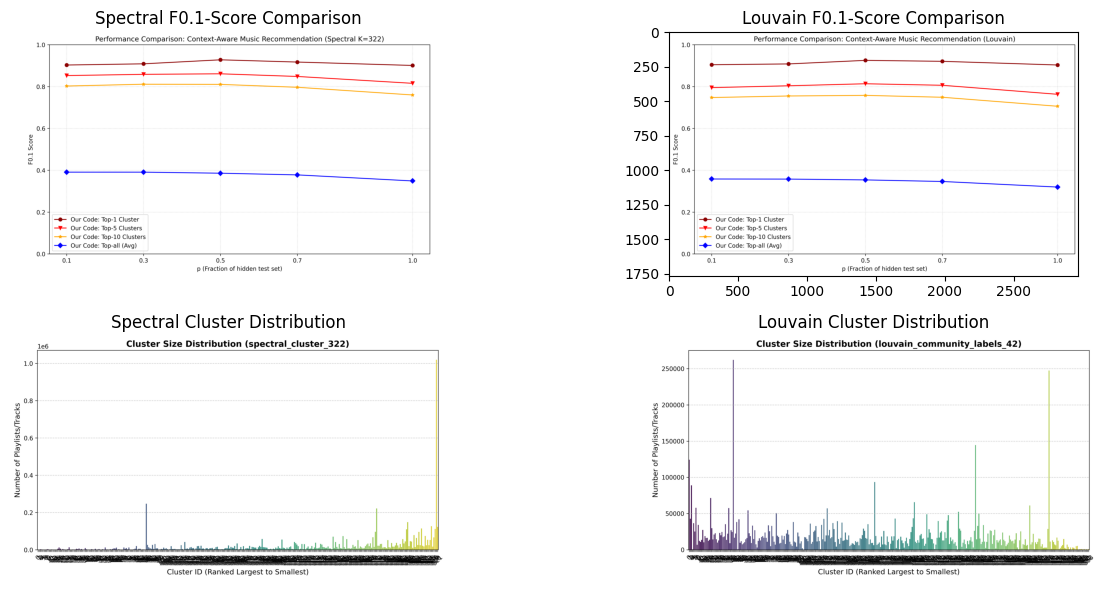

In [20]:
# Plotting the results side by side for comparison
spectral_322_path_fscore = os.path.join(spectral_report_out_322, "f01_comparison.png")
louvain_path_fscore = os.path.join(louvain_report_out, "f01_comparison.png")

spectral_322_path_dist = os.path.join(spectral_report_out_322, "cluster_distribution.png")
louvain_path_dist = os.path.join(louvain_report_out, "cluster_distribution.png")

# Plotting them side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes[0, 0].imshow(plt.imread(spectral_322_path_fscore))
axes[0, 0].set_title(f"{Spectral_322.algo_name} F0.1-Score Comparison")
axes[0, 0].axis('off')
axes[0, 1].imshow(plt.imread(louvain_path_fscore))
axes[0, 1].set_title(f"{Louvain.algo_name} F0.1-Score Comparison")
axes[1, 0].imshow(plt.imread(spectral_322_path_dist))
axes[1, 0].set_title(f"{Spectral_322.algo_name} Cluster Distribution")
axes[1, 0].axis('off')
axes[1, 1].imshow(plt.imread(louvain_path_dist))
axes[1, 1].set_title(f"{Louvain.algo_name} Cluster Distribution")
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

#### Overall Predictive Trends
The evaluation results for our graph-based algorithms, Spectral Clustering and Louvain Community Detection, demonstrate a drastic improvement over the geometric approaches applied in Module 1. Both graph-based methods achieved exceptional predictive performance, with Top-1 Cluster $F_{0.1}$ scores peaking around 0.90 to 0.92 across all test fractions. 

It is important to acknowledge that a portion of this improvement stems from the significantly higher cluster granularity ($k=322$ vs $k=55$), which naturally creates tighter neighbourhoods and narrows the collaborative filtering search space. However, this high granularity is a direct benefit of our topological restructuring. K-means was proved by WCSS to provide diminishing returns at higher $k$ values, while the graph-based models successfully isolate 322 'optimal' communities.

Furthermore, if the algorithms were overfitting by creating artificially small clusters, their accuracy would plummet rapidly when forced to recommend higher fractions of the test set. Instead, both models exhibit strong resilience to increases in recommendation density ($p$), seeing only minor degradations as $p$ approaches 1.0. We attribute both these findings to the rich boundaries formed by the local contextual links in our graph preprocessing, forming semantic clusters where the recommendation system can continue to find relevant tracks even on higher quotas.


#### Spectral vs. Louvain
While both models peak at around 0.90 to 0.92 for Top-1 $F_{0.1}$ scores, Spectral Clustering demonstrates a structural advantage in broader recommendation brackets. It maintains noticeably higher Top-5 and Top-10 scores than Louvain, indicating more stable macro-partitions. This indicates that while Louvain's bottom up approach is able to find localized pockets of similarity, Spectral's approach of a Top-Down Global partitioning provides a more reliable recommendation across the entire dataset.

### Hypothesis For Limitations and Potential Improvements
While the shift to a network structure successfully mitigated the "gravity well" effect and improved our predictive baseline, the underlying methodology relies on assumptions that introduce new structural limitations. We hypothesize the following limitations and propose corresponding improvements:

#### K-NN Graph Limitations
**Limitation:** The creation of our K-NN graph involved setting the parameter $k=10$, signifying the amount of connections per cluster. However, this assumes that the musical landscape has a uniform density. In reality, mainstream contexts perhaps form large highly dense communities, while niche sub-genres form isolated more sparse pockets. A fixed $k$ artificially limits the natural connectivity of mainstream hubs while forcing weak connections upon other nodes, just to meet our defined quota.

**Improvement (Adaptive Neighbourhood Topologies):**  We propose replacing the rigid K-NN graph with a dynamic topology, specifically Mutual $k$-Nearest Neighbours (m-kNN) or an $\epsilon$-radius neighbourhood graph. By removing strict degree quotas, these methods accurately reflect the underlying data density by maintaining robust intra-cluster edges within mainstream hubs while isolating sparse outliers to prevent artificial bridging.

#### The Modularity Resolution Limit
**Limitation:** Louvain successfully constructs neighbourhoods based on local density, but its reliance on optimizing global Modularity leaves it highly susceptible to the "Resolution Limit." In a network of our scale (over 84,000 nodes and 640,000 edges) we hypothesize that with a resolution parameter of 1, Louvain is struggling to find small strongly connected communities, as the expected number of edges within it becomes so tiny that even a single edge connecting two small distinct communities can cause the algorithm to merge them.

**Improvement (Leiden Algorithm):** The Leiden Algorithm is an evolution of Louvain which adresses a number of key issues. The Leiden algorithm employs an intermediate refinement phase in which communities may be split to guarantee that all communities are well-connected. When paired with resolution-limit-free quality functions like the Constant Potts Model (CPM), this refinement ensures small, dense communities are accurately identified without being artificially merged (CITE).

#### Method Limits in Deterministic Partitioning
**Limitation:** In the above experiment we forced Spectral Clustering to partition the network into exactly 322 clusters to establish a controlled comparison with the Louvain baseline. However, as these two models are in many ways structural and algorithmic opposites, we hypothesise that we may be artificially locking Spectral to this cluster amount may be handicapping its linear algebraic logic. This argument could perhaps also be applied to the results from BIRCH in part 1, as the hierarchical clustering algorithm may benefit from a different granularity that the one selected for k-Means. 

**Improvement (Eigengap Heuristic):**
Rather than forcing Spectral Clustering to inherit k=322, we can let the graph structure determine its own natural partition size through the Eigengap heuristic. This method examines the eigenvalues of the normalized graph Laplacian and identifies the largest gap between consecutive eigenvalues, which indicates a stable transition in the network's connectivity structure. This should find Spectral Clustering a parameter based on the topology of the data itself, rather than the imposed one.


### From KNN to MKNN
The original k-nearest neighbour graph connects each playlist to its $k$ most similar neighbours, but those links are not necessarily reciprocal. A playlist may points to another node without being selected back in return, which can introduce weak one-way bridges in the network. To make topology more conservative, we convert the graph into a mutual k-nearest neighbour graph by keeping only edges that are supported in both directions. This removes ubstable connections and leaves a structure that better reflects stable local simmilarity. 

KNN Directed Adjacency Matrix ($A$):

$$A_{ij} = \begin{cases} 1, & \text{if } j \in N_k(i) \\ 0, & \text{otherwise} \end{cases}$$

MKNN Undirected Adjacency Matrix ($M$): Using the Hadamard (element-wise) matrix product: $$M = A \circ A^T$$

Expressed as an element-wise computation: 

$$M_{ij} = A_{ij} \times A_{ji}$$

$$M_{ij} = \begin{cases} 1, & \text{if } A_{ij} = 1 \text{ and } A_{ji} = 1 \\ 0, & \text{otherwise} \end{cases}$$

In our case, this also makes the graph significantly sparser and more fragmented, especially with $k = 10$ and a similarity threshold of 0.15. This can be useful for isolating genuinely coherent neighbourhoods, but it also means downstream methods such as Spectral Clustering becomes more sensitive to paramter choice. If pruning is too aggresive, useful connectivity can disappear, which may hurt performance rather than improve it. 

In [32]:
from graph.m_knn.m_knn_graph import M_KNN
MKNN = M_KNN(graph_builder.DiG)

# Now we are building the M-KNN graph, which will be used for the next clustering step. 
# 
# This is a bit time consuming, so we can optionally set force_rebuild to True to ensure we are building it fresh, otherwise loading from cache.
m_knn_graph = MKNN.build_graph(force_rebuild=False)

Loading mutual k-NN NetworkX graph from .pkl file...


After constructing the mutual k-nearest neighbour graph, we remove isolated nodes, meaning playlists that no longer have any edges after the reciprocity filter is applied. In practice we first create a copy of the graph, and then delete every zero-degree node, effectively removing points that carry no local neighbourhood information. 

This makes the graph more suitable for Spectral Clustering, since isolated vertices do not help define coherent cuts and can weaken the structure of the adjacency matrix. The trade-off is that the resulting graph becomes smaller and more selective: it emphasizes the connected core of the data while excluding playlists that are too weakly linked to participate in a mutual neighbourhood. For that reason, the no-isolates graph should be interpreted as a refined analysis graph rather than a complete representation of the original dataset.

In [22]:
# Removing isolates
m_knn_graph_no_isolates = m_knn_graph.copy()
m_knn_graph_no_isolates.remove_nodes_from(list(nx.isolates(m_knn_graph_no_isolates)))

In [34]:
# Running Spectral Clustering on the M-KNN graph, for k = 322
Spectral_MKNN_322 = SpectralGraphClustering(graph=m_knn_graph_no_isolates, n_clusters=322, graph_config_name=digraph_config_name)
Spectral_MKNN_322.cluster_col += "_mknn" # small hack: differentiate cluster col name

execution_pipeline(Spectral_MKNN_322, df, unique_texts, tfidf_matrix)

Checking for: 'spectral_cluster_322_mknn' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Spectral already exists in column 'spectral_cluster_322_mknn'.


In [35]:
# Evaluating Spectral Clustering on M-KNN graph
spectral_report_out_mknn_322 = evaluation_pipeline(Spectral_MKNN_322, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_mknn_k322/evaluation_metrics_spectral_cluster_322_mknn.txt'.


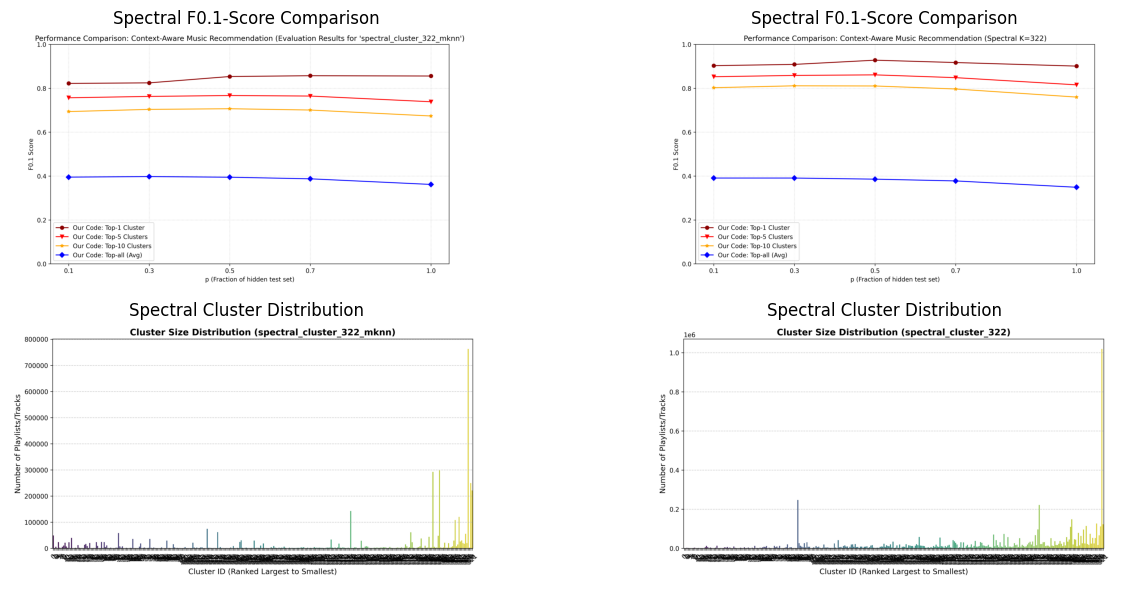

In [30]:
# Plotting the results of Spectral Clustering on M-KNN graph, side by side with the original Spectral Clustering results
spectral_mknn_322_path_fscore = os.path.join(spectral_report_out_mknn_322, "f01_comparison.png")
spectral_322_path_fscore = os.path.join(spectral_report_out_322, "f01_comparison.png")
spectral_mknn_322_path_dist = os.path.join(spectral_report_out_mknn_322, "cluster_distribution.png")
spectral_322_path_dist = os.path.join(spectral_report_out_322, "cluster_distribution.png")
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes[0, 0].imshow(plt.imread(spectral_mknn_322_path_fscore))
axes[0, 0].set_title(f"{Spectral_MKNN_322.algo_name} F0.1-Score Comparison")
axes[0, 0].axis('off')
axes[0, 1].imshow(plt.imread(spectral_322_path_fscore))
axes[0, 1].set_title(f"{Spectral_322.algo_name} F0.1-Score Comparison")
axes[0, 1].axis('off')
axes[1, 0].imshow(plt.imread(spectral_mknn_322_path_dist))
axes[1, 0].set_title(f"{Spectral_MKNN_322.algo_name} Cluster Distribution")
axes[1, 0].axis('off')
axes[1, 1].imshow(plt.imread(spectral_322_path_dist))
axes[1, 1].set_title(f"{Spectral_322.algo_name} Cluster Distribution")
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

The mutual k-nearest neighbour variant produced a more conservative graph, but in this case that conservatism appears to have been excessive. By retaining only reciprocal edges and removing isolated nodes, we reduced the graph’s connectivity and fragmented several neighborhoods that were previously useful for spectral partitioning. The result is a noticeable drop in Top-1, Top-5, and Top-10 performance, which suggests that the original k-NN graph contained weak but still informative bridging structure that helped Spectral Clustering form more predictive communities. In other words, the MKNN graph is structurally cleaner, but for this dataset and parameter setting it is also too sparse to preserve enough semantic continuity for optimal clustering.

#### Potential Improvements
Instead of fixing $k=10$ and applying a hard similarity threshold of 0.15, we could have tuned the graph construction parameters jointly with the downstream clustering objective. A slightly denser mutual graph would likely have retained more useful intra-community structure while still filtering out the most unstable cross-links.

##### Improvement (Weighted Mutual Graph)
Rather than converting the mutual graph into a purely structural topology, we could have preserved the cosine similarity weights after the reciprocity filter. This would allow Spectral Clustering to distinguish strong reciprocal links from weak ones, instead of treating all surviving edges as equally informative.

##### Improvement (Component-Aware Spectral Clustering)
Instead of removing all isolates and fitting one global spectral model, we could have handled connected components separately or kept the isolated nodes as singleton cases. That would reduce the loss of rare but meaningful contexts and avoid over-fragmenting the graph before clustering.

##### Improvement (Graph-Specific $k$ Selection)
Finally, the choice of $k=322$ should not be assumed to transfer directly from the original KNN graph to the MKNN graph. Since the mutual graph has a different density profile, its optimal number of clusters should be re-estimated directly on the new topology, for example using an eigengap or silhouette-based search.

Overall, the main lesson is that structural cleaning is not always beneficial by itself. For this dataset, the MKNN graph became cleaner, but also too sparse, which suggests that preserving a small amount of weak connectivity was necessary for better clustering performance.